# YOLOv8 모델 학습
### 사전학습 가중치 (COCO)로 전이학습
### 모델 크기 선택 가이드 :
- 모델 (yolov8n) : 특징 (가장 빠름, 정확도 낮음 (빠른 실험용))
- 모델 (yolov8s) : 특징 (속도 / 정확도 균형 <- 권장)
- 모델 (yolov8m) : 특징 (정확도 높음, 속도 보통)

In [19]:
from ultralytics import YOLO
import torch
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

# GPU 확인
if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    vram     = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f'[GPU] {gpu_name}  ({vram:.1f} GB VRAM)')
    if vram < 6:
        print('[TIP] VRAM 부족 → batch=8, imgsz=416 으로 줄이세요')
else:
    print('[CPU] GPU 없음 → 학습이 느릴 수 있습니다')

[GPU] NVIDIA GeForce RTX 5060 Laptop GPU  (8.5 GB VRAM)


### 하이퍼파라미터 설정

In [20]:
DATASET_YAML = "./pcb_yolo_dataset/dataset.yaml"  # STEP 2에서 생성된 파일
PROJECT_NAME = "pcb_defect_detection"
RUN_NAME     = "yolov8s_transfer"
MODEL_WEIGHTS = "yolov8s.pt"   # n / s / m 중 선택

HYPERPARAMS = {
    "data"         : DATASET_YAML,
    "epochs"       : 100,
    "imgsz"        : 640,
    "batch"        : 16,      # GPU 메모리 부족 시 8로 줄이세요
    "lr0"          : 0.01,
    "lrf"          : 0.01,
    "momentum"     : 0.937,
    "weight_decay" : 0.0005,
    "warmup_epochs": 3,
    "patience"     : 20,      # Early Stopping
    "optimizer"    : "SGD",
    "project"      : PROJECT_NAME,
    "name"         : RUN_NAME,
    "exist_ok"     : True,
    "pretrained"   : True,    # 전이학습 사용
    "device"       : 0 if torch.cuda.is_available() else "cpu",
    # 데이터 증강
    "hsv_h"        : 0.015,
    "hsv_s"        : 0.7,
    "hsv_v"        : 0.4,
    "degrees"      : 5.0,
    "translate"    : 0.1,
    "scale"        : 0.5,
    "fliplr"       : 0.5,
    "mosaic"       : 1.0,
    "mixup"        : 0.1,
}

print(f'모델: {MODEL_WEIGHTS}')
print(f'데이터: {DATASET_YAML}')
print(f'디바이스: {HYPERPARAMS["device"]}')

모델: yolov8s.pt
데이터: ./pcb_yolo_dataset/dataset.yaml
디바이스: 0


In [ ]:
# BASE = Path(r"C:\workspace_python\deeplearning\project")

# DATASET_YAML  = str(BASE / "pcb_yolo_dataset/dataset.yaml")
# PROJECT_NAME  = "pcb_defect_detection"
# RUN_NAME      = "yolov8s_v3"   # ✅ 이름 변경
# MODEL_WEIGHTS = "yolov8s.pt"

# HYPERPARAMS = {
#     "data"         : DATASET_YAML,
#     "epochs"       : 50,       # ✅ 50으로 줄이기
#     "imgsz"        : 640,
#     "batch"        : 8,
#     "lr0"          : 0.001,
#     "lrf"          : 0.01,
#     "momentum"     : 0.937,
#     "weight_decay" : 0.0005,
#     "warmup_epochs": 3,
#     "patience"     : 30,
#     "optimizer"    : "AdamW",  # ✅ SGD → AdamW
#     "project"      : PROJECT_NAME,
#     "name"         : RUN_NAME,
#     "exist_ok"     : True,
#     "pretrained"   : True,
#     "device"       : 0 if torch.cuda.is_available() else "cpu",
#     "workers"      : 0,        # ✅ Windows 오류 방지
#     "hsv_h"        : 0.015,
#     "hsv_s"        : 0.7,
#     "hsv_v"        : 0.4,
#     "degrees"      : 15.0,
#     "translate"    : 0.1,
#     "scale"        : 0.7,
#     "fliplr"       : 0.5,
#     "mosaic"       : 1.0,
#     "mixup"        : 0.2,
# }

# print(f'모델:     {MODEL_WEIGHTS}')
# print(f'실행명:   {RUN_NAME}')
# print(f'데이터:   {DATASET_YAML}')
# print(f'디바이스: {HYPERPARAMS["device"]}')

모델:     yolov8s.pt
실행명:   yolov8s_v3
데이터:   C:\workspace_python\deeplearning\project\pcb_yolo_dataset\dataset.yaml
디바이스: 0


In [ ]:
# RUN_NAME = "yolov8s_v4"

# HYPERPARAMS = {
#     "data"         : DATASET_YAML,
#     "epochs"       : 150,      # ✅ 150 에폭
#     "imgsz"        : 640,
#     "batch"        : 8,
#     "lr0"          : 0.01,     # ✅ 원래대로 복구
#     "lrf"          : 0.01,
#     "momentum"     : 0.937,
#     "weight_decay" : 0.0005,
#     "warmup_epochs": 3,
#     "patience"     : 50,       # ✅ 조기종료 완화
#     "optimizer"    : "SGD",    # ✅ SGD로 복구
#     "project"      : PROJECT_NAME,
#     "name"         : RUN_NAME,
#     "exist_ok"     : True,
#     "pretrained"   : True,
#     "device"       : 0 if torch.cuda.is_available() else "cpu",
#     "workers"      : 0,
#     "hsv_h"        : 0.015,
#     "hsv_s"        : 0.7,
#     "hsv_v"        : 0.4,
#     "degrees"      : 15.0,
#     "translate"    : 0.1,
#     "scale"        : 0.7,
#     "fliplr"       : 0.5,
#     "mosaic"       : 1.0,
#     "mixup"        : 0.2,
# }

# print(f'실행명: {RUN_NAME}')
# print(f'옵티마이저: {HYPERPARAMS["optimizer"]}')
# print(f'학습률: {HYPERPARAMS["lr0"]}')

실행명: yolov8s_v4
옵티마이저: SGD
학습률: 0.01


### 모델 학습

In [21]:
print(f'[START] 모델 로드: {MODEL_WEIGHTS}')
model = YOLO(MODEL_WEIGHTS)  # 사전학습 가중치 자동 다운로드

print(f'[START] 학습 시작...')
results = model.train(**HYPERPARAMS)

best_weights = Path(PROJECT_NAME) / RUN_NAME / "weights" / "best.pt"
print(f'\n[DONE] 학습 완료!')
print(f'[BEST] 최적 가중치 경로: {best_weights}')

[START] 모델 로드: yolov8s.pt
[START] 학습 시작...
Ultralytics 8.4.33  Python-3.11.15 torch-2.12.0.dev20260324+cu128 CUDA:0 (NVIDIA GeForce RTX 5060 Laptop GPU, 8151MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=./pcb_yolo_dataset/dataset.yaml, degrees=5.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8s_transfer, nbs=64, nms=False,

In [ ]:
# import yaml
# from pathlib import Path

# # 1. 설정 파일 내용 읽기
# yaml_path = "./pcb_yolo_dataset/dataset.yaml"
# if Path(yaml_path).exists():
#     with open(yaml_path, 'r') as f:
#         data_config = yaml.safe_load(f)
    
#     print("--- dataset.yaml 설정 내용 ---")
#     print(data_config)
    
#     # 2. 경로 실제 존재 여부 체크
#     base_path = Path(data_config['path'])
#     train_path = base_path / data_config['train']
#     val_path = base_path / data_config['val']
    
#     print(f"\n--- 경로 점검 결과 ---")
#     print(f"루트 경로 존재: {base_path.exists()} ({base_path})")
#     print(f"학습 데이터 존재: {train_path.exists()} ({train_path})")
#     print(f"검증 데이터 존재: {val_path.exists()} ({val_path})")
# else:
#     print(f"❌ {yaml_path} 파일을 찾을 수 없습니다.")

--- dataset.yaml 설정 내용 ---
{'path': 'C:\\workspace_python\\deeplearning\\project\\pcb_yolo_dataset', 'train': 'train/images', 'val': 'val/images', 'test': 'test/images', 'nc': 6, 'names': ['missing_hole', 'mouse_bite', 'open_circuit', 'short', 'spur', 'spurious_copper']}

--- 경로 점검 결과 ---
루트 경로 존재: True (C:\workspace_python\deeplearning\project\pcb_yolo_dataset)
학습 데이터 존재: True (C:\workspace_python\deeplearning\project\pcb_yolo_dataset\train\images)
검증 데이터 존재: True (C:\workspace_python\deeplearning\project\pcb_yolo_dataset\val\images)


In [ ]:
# from ultralytics import YOLO
# import torch

# # 1. 모델 로드
# model = YOLO("yolov8s.pt")

# # 2. HYPERPARAMS에서 중복될 수 있는 값들을 미리 수정/추가
# HYPERPARAMS["workers"] = 0   # Windows 환경 에러 방지
# HYPERPARAMS["amp"] = False   # 안정적인 학습을 위해 끔
# HYPERPARAMS["exist_ok"] = True # 폴더가 이미 있어도 덮어쓰기

# # 3. 학습 실행 (직접 인자를 추가하지 말고 언패킹만 사용)
# print(f"[START] 학습 시작 (Device: {HYPERPARAMS['device']})")
# results = model.train(**HYPERPARAMS)

[START] 학습 시작 (Device: 0)
Ultralytics 8.4.33  Python-3.11.15 torch-2.12.0.dev20260324+cu128 CUDA:0 (NVIDIA GeForce RTX 5060 Laptop GPU, 8151MiB)
engine\trainer: agnostic_nms=False, amp=False, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=./pcb_yolo_dataset/dataset.yaml, degrees=5.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8s_transfer, nbs=64, nms=False, opset=None, opt

In [ ]:
# from ultralytics import YOLO
# import torch

# model = YOLO(MODEL_WEIGHTS)

# print(f'[START] 학습 시작 (Device: {HYPERPARAMS["device"]})')
# results = model.train(**HYPERPARAMS)

# best_weights = BASE / f"runs/detect/{PROJECT_NAME}/{RUN_NAME}/weights/best.pt"
# print(f'\n[DONE] 학습 완료!')
# print(f'[BEST] 가중치 경로: {best_weights}')
# print(f'[BEST] 파일 존재: {best_weights.exists()}')

[START] 학습 시작 (Device: 0)
Ultralytics 8.4.33  Python-3.11.15 torch-2.12.0.dev20260324+cu128 CUDA:0 (NVIDIA GeForce RTX 5060 Laptop GPU, 8151MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\workspace_python\deeplearning\project\pcb_yolo_dataset\dataset.yaml, degrees=15.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.2, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8s_v3, nb

In [ ]:
# from ultralytics import YOLO
# import torch

# model = YOLO(MODEL_WEIGHTS)

# print(f'[START] 학습 시작 (Device: {HYPERPARAMS["device"]})')
# results = model.train(**HYPERPARAMS)

# best_weights = BASE / f"runs/detect/{PROJECT_NAME}/{RUN_NAME}/weights/best.pt"
# print(f'\n[DONE] 학습 완료!')
# print(f'[BEST] 가중치 경로: {best_weights}')
# print(f'[BEST] 파일 존재: {best_weights.exists()}')

[START] 학습 시작 (Device: 0)
Ultralytics 8.4.33  Python-3.11.15 torch-2.12.0.dev20260324+cu128 CUDA:0 (NVIDIA GeForce RTX 5060 Laptop GPU, 8151MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\workspace_python\deeplearning\project\pcb_yolo_dataset\dataset.yaml, degrees=15.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.2, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8s_v4, nb

### 학습 곡선 시각화

In [22]:
csv_path = Path(PROJECT_NAME) / RUN_NAME / "results.csv"

if not csv_path.exists():
    print(f'[WARN] results.csv 없음: {csv_path}')
else:
    df = pd.read_csv(csv_path)
    df.columns = df.columns.str.strip()

    fig, axes = plt.subplots(2, 3, figsize=(16, 8))
    fig.suptitle("YOLOv8 Training Curves - PCB Defect Detection",
                 fontsize=14, fontweight="bold")

    plot_targets = [
        ("train/box_loss",      "Box Loss (Train)",    "#E63946"),
        ("train/cls_loss",      "Class Loss (Train)",  "#457B9D"),
        ("train/dfl_loss",      "DFL Loss (Train)",    "#2A9D8F"),
        ("val/box_loss",        "Box Loss (Val)",      "#F4A261"),
        ("metrics/mAP50(B)",    "mAP@0.5",             "#E63946"),
        ("metrics/mAP50-95(B)", "mAP@0.5:0.95",       "#457B9D"),
    ]

    for ax, (col, title, color) in zip(axes.flat, plot_targets):
        if col in df.columns:
            ax.plot(df["epoch"], df[col], color=color, linewidth=2)
            ax.set_title(title, fontsize=11)
            ax.set_xlabel("Epoch")
            ax.grid(True, alpha=0.3)
        else:
            ax.set_title(f"{title}\n(데이터 없음)", fontsize=10)
            ax.axis("off")

    plt.tight_layout()

    # ✅ out_path도 동일하게 절대경로로 수정
    out_path = csv_path.parent / "training_curves.png"
    plt.savefig(out_path, dpi=150)
    plt.show()
    print(f'[SAVE] {out_path}')

[WARN] results.csv 없음: pcb_defect_detection\yolov8s_transfer\results.csv


In [23]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# 1. 'runs' 또는 프로젝트 폴더 내의 모든 results.csv 검색
# 현재 위치 기준으로 가장 최근에 수정된 파일을 찾습니다.
csv_files = list(Path(".").rglob("results.csv"))

if not csv_files:
    print("❌ 아직 생성된 results.csv 파일이 없습니다. 1 에폭이 끝날 때까지 기다려주세요!")
else:
    # 가장 최근에 업데이트된 파일 선택
    latest_csv = max(csv_files, key=lambda x: x.stat().st_mtime)
    print(f"✅ 최신 결과 파일 발견: {latest_csv}")
    
    df = pd.read_csv(latest_csv)
    df.columns = df.columns.str.strip()

    # --- 여기서부터 시각화 그래프 그리기 시작 ---
    fig, axes = plt.subplots(2, 3, figsize=(16, 8))
    # ... (기존 시각화 로직 동일)
    plt.show()

✅ 최신 결과 파일 발견: runs\detect\pcb_defect_detection\yolov8s_transfer\results.csv


<Figure size 1600x800 with 6 Axes>

In [24]:
import pandas as pd
from pathlib import Path

csv_path = Path(r"runs\detect\pcb_defect_detection\yolov8s_transfer\results.csv")
df = pd.read_csv(csv_path)

# 공백 제거
df.columns = df.columns.str.strip()

print(f"현재 기록된 에폭 수: {len(df)}")
display(df.head()) # 데이터 내용 출력

현재 기록된 에폭 수: 100


,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
0,1,9.01073,5.14141,28.37530,2.66138,0.00010,0.00939,0.00006,0.00002,4.77727,5.09539,2.16119,0.003000,0.003000,0.073000
1,2,16.74730,4.17797,5.18391,1.72591,0.00021,0.03331,0.00024,0.00007,4.13516,4.23454,1.59675,0.006040,0.006040,0.045040
2,3,24.07130,3.98162,4.82978,1.48285,0.00046,0.05638,0.00315,0.00143,3.87543,4.11851,1.52131,0.009018,0.009018,0.017018
3,4,31.44390,3.84017,4.68528,1.45655,0.53901,0.02991,0.01177,0.00389,3.87274,7.35338,1.53490,0.009703,0.009703,0.009703
4,5,38.88890,3.86020,4.61093,1.43549,0.02404,0.05599,0.01591,0.00562,3.85995,4.40595,1.52965,0.009604,0.009604,0.009604


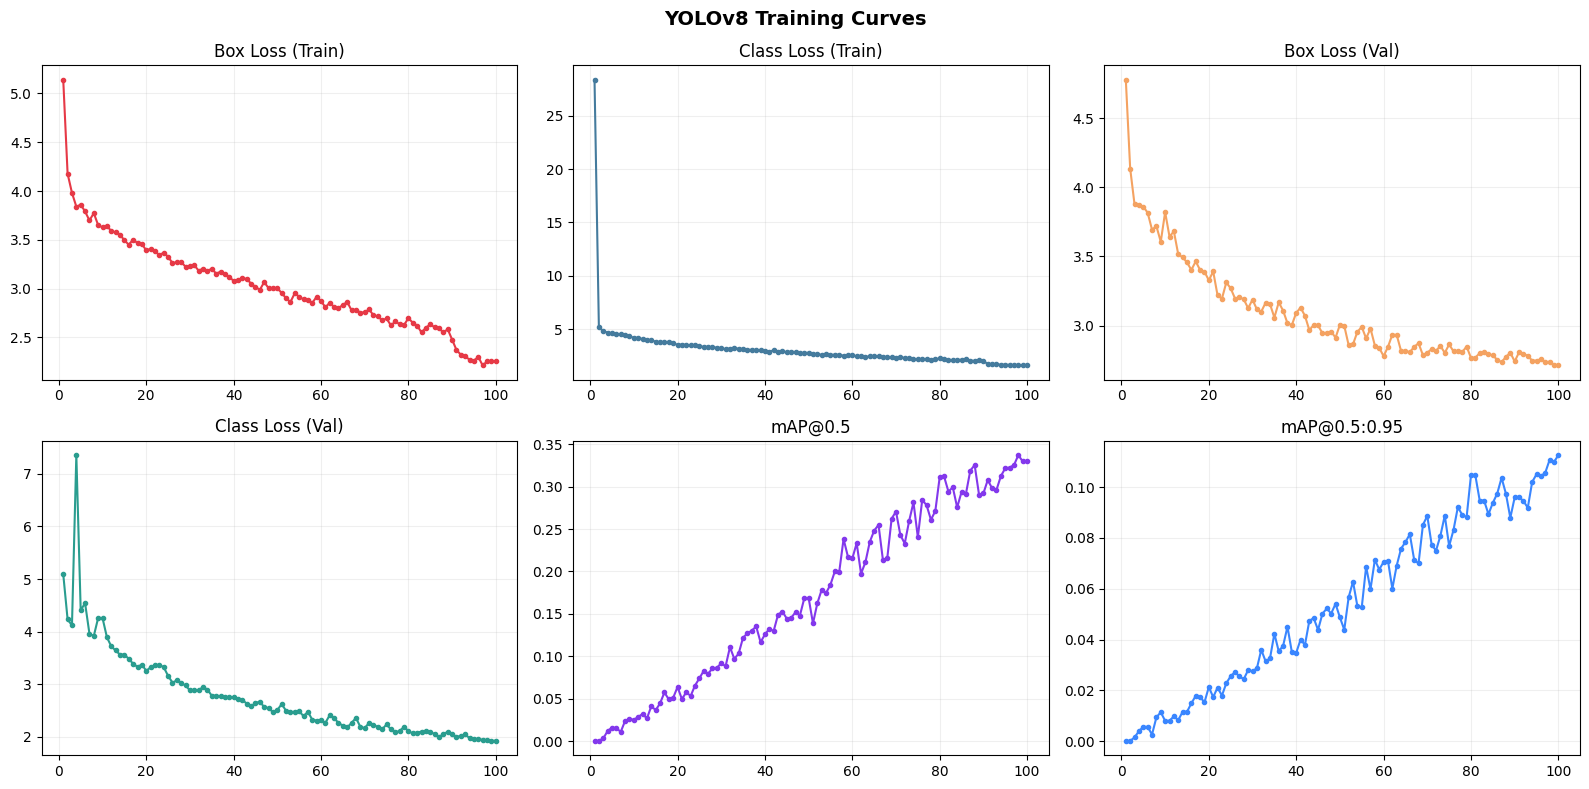

In [25]:
%matplotlib inline
import matplotlib.pyplot as plt

# 폰트 및 스타일 설정
plt.rcParams['figure.facecolor'] = 'white'

if len(df) > 0:
    fig, axes = plt.subplots(2, 3, figsize=(16, 8))
    fig.suptitle("YOLOv8 Training Curves", fontsize=14, fontweight="bold")

    plot_targets = [
        ("train/box_loss", "Box Loss (Train)", "#E63946"),
        ("train/cls_loss", "Class Loss (Train)", "#457B9D"),
        ("val/box_loss", "Box Loss (Val)", "#F4A261"),
        ("val/cls_loss", "Class Loss (Val)", "#2A9D8F"),
        ("metrics/mAP50(B)", "mAP@0.5", "#8338EC"),
        ("metrics/mAP50-95(B)", "mAP@0.5:0.95", "#3A86FF"),
    ]

    for ax, (col, title, color) in zip(axes.flat, plot_targets):
        if col in df.columns:
            ax.plot(df["epoch"], df[col], color=color, marker='o', markersize=3)
            ax.set_title(title)
            ax.grid(True, alpha=0.2)
        else:
            ax.set_title(f"{title} (No Data)")

    plt.tight_layout()
    plt.show()
else:
    print("⚠️ 아직 기록된 데이터가 없습니다. 학습이 더 진행된 후에 다시 실행해 주세요.")